# Dependence Penalties: Fair KRR, LapRLS, Supervised and Fair Kernel PCA, Pre-images

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/dependence_penalties.ipynb)

A dependence measure is also a regulariser. Add $\mu\,\mathrm{HSIC}(f, s)$ to a regression loss and the predictions are pushed towards independence from $s$; add the smoothness $f^\top L f$ along a graph and unlabelled points start to shape the fit; add $\gamma\,\mathrm{HSIC}(Z, t)$ to kernel PCA and the components keep (or drop) the information in $t$. kernellib exposes these as neutral building blocks: `KRR(penalty_weight=...).fit(X, y, penalty=..., mask=...)` with `hsic_penalty` or `laplacian_penalty`, and `KernelPCA(target_weight=...).fit(X, target=...)`. Nothing is named "fair": fairness is one use among several.

**What you'll learn:**

1. Fair kernel ridge regression on the Adult census, with the whole accuracy–dependence curve from the closed form (one linear system per $\mu$)
2. The nonlinear version: an MLP trained with a `kl.cka` penalty, as a pipekit-train `TrainTask`
3. Laplacian-regularised least squares (LapRLS) on two moons, from two labels
4. Supervised and fair kernel PCA, one eigenproblem with the sign of $\gamma$ switched
5. Denoising by kernel PCA projection and a learned pre-image

## Background

`KRR` with a penalty operator $M$, a mask $J$ of labelled points ($l = \operatorname{tr}J$) and weight $\mu$ minimises

$$\frac1l\|J(y - K\alpha)\|^2 + \lambda\,\alpha^\top K\alpha + \mu\,\alpha^\top K M K\alpha \quad\Longrightarrow\quad (JK + l\lambda I + l\mu\,MK)\,\alpha = Jy .$$

Two choices of $M$ give two literatures:

- `hsic_penalty(kernel, S)` sets $M = HK_sH/n^2$, so the penalty is the biased HSIC between the predictions $f = K\alpha$ (under a linear kernel) and protected attributes $S$: fair kernel learning (Pérez-Suay et al., 2017). With a `Linear` kernel on $S$, $M$ has rank $P$ (the number of attributes) and the fit costs $P + 1$ ordinary KRR solves (Woodbury).
- `laplacian_penalty(W)` sets $M = L/n^2$ for a graph Laplacian, so the penalty is the Dirichlet energy of $f$ on the graph: Laplacian-regularised least squares (Belkin, Niyogi & Sindhwani, 2006). With a mask, unlabelled points enter only through the penalty.

Kernel PCA with a target kernel $K_T$ maximises the variance plus $\gamma$ times the linear-kernel HSIC between the components $Z$ and the target $T$. $\gamma > 0$ is supervised kernel PCA (Barshan et al., 2011), $\gamma < 0$ fair kernel PCA, and both reduce to one small symmetric eigenproblem.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    pipekit = "git+https://github.com/jejjohnson/pipekit.git@pipekit-train-v0.0.2"
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
            "scikit-learn",
            "optax",
            f"pipekit @ {pipekit}#subdirectory=packages/pipekit",
            f"pipekit-train[equinox] @ {pipekit}#subdirectory=packages/pipekit-train",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import logging
import time

import einx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from pipekit_train import TrainingDataset, TrainingLoop
from pipekit_train.adapters.equinox import EquinoxModelOp
from sklearn.datasets import fetch_openml, load_digits, make_moons

import kernellib as kl


jax.config.update("jax_enable_x64", True)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
notebook_start = time.perf_counter()

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,optax,pipekit_train,matplotlib,sklearn,kernellib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.17.1

jax          : 0.11.2
equinox      : 0.13.8
optax        : 0.2.8
pipekit_train: 0.0.2
matplotlib   : 3.11.2
sklearn      : 1.9.1
kernellib    : 0.0.16

Compiler    : Clang 21.1.4 
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## The Adult census

The Adult census (48,842 rows) asks whether a person earns more than \$50K a year. We take a random subsample of 5,000 rows (seed 0), 3,000 for training and 2,000 for testing, and regress the 0/1 income indicator. The inputs are age, years of education, $\log(1 + \text{capital gain})$, $\log(1 + \text{capital loss})$ and hours per week (standardised), plus one-hot work class, marital status, occupation and relationship (a missing category is the zero vector). The protected attributes are **sex** (1 = male) and **race** (1 = white). They are *not* inputs, but marital status and relationship ("husband", "wife") are strong proxies for sex, so dropping the attribute is not enough to make predictions independent of it. `fetch_openml(..., as_frame=False)` returns the categoricals as integer codes, which keeps pandas out of the dependencies.

In [4]:
adult = fetch_openml("adult", version=2, as_frame=False, parser="liac-arff")
column = {name: i for i, name in enumerate(adult.feature_names)}
order = np.random.default_rng(0).permutation(adult.data.shape[0])[:5000]
raw = adult.data[order]
income = (adult.target[order] == ">50K").astype(float)


def one_hot(name):
    codes = raw[:, column[name]]
    known = ~np.isnan(codes)
    out = np.zeros((len(codes), len(adult.categories[name])))
    out[np.flatnonzero(known), codes[known].astype(int)] = 1.0
    return out


numeric = np.stack(
    [
        raw[:, column["age"]],
        raw[:, column["education-num"]],
        np.log1p(raw[:, column["capital-gain"]]),
        np.log1p(raw[:, column["capital-loss"]]),
        raw[:, column["hours-per-week"]],
    ],
    axis=-1,
)
mean, std = einx.mean("n d -> d", numeric), einx.std("n d -> d", numeric)
numeric = einx.divide(
    "n d, d -> n d", einx.subtract("n d, d -> n d", numeric, mean), std
)
categorical = [
    one_hot(name)
    for name in ["workclass", "marital-status", "occupation", "relationship"]
]
inputs = np.concatenate([numeric, *categorical], axis=-1)
male = raw[:, column["sex"]] == adult.categories["sex"].index("Male")
white = raw[:, column["race"]] == adult.categories["race"].index("White")
protected = np.stack([male, white], axis=-1).astype(float)

n_train = 3000
X, X_test = jnp.asarray(inputs[:n_train]), jnp.asarray(inputs[n_train:])
y, y_test = jnp.asarray(income[:n_train]), jnp.asarray(income[n_train:])
S, S_test = jnp.asarray(protected[:n_train]), jnp.asarray(protected[n_train:])
print(f"inputs {X.shape} train, {X_test.shape} test")
print(f"P(>50K) = {float(jnp.mean(y)):.3f}, P(male) = {float(jnp.mean(S[:, 0])):.3f}")
print(f"P(white) = {float(jnp.mean(S[:, 1])):.3f}")
print(f"majority-class test accuracy = {float(jnp.mean(y_test == 0)):.4f}")

inputs (3000, 40) train, (2000, 40) test


P(>50K) = 0.258, P(male) = 0.670
P(white) = 0.850


majority-class test accuracy = 0.7590


## Fair KRR: the trade-off curve from the closed form

The kernel is an RBF with the median-heuristic lengthscale and $\lambda = 10^{-3}$. `hsic_penalty(kl.Linear(), S)` is the rank-2 operator $HSS^\top H/n^2$, so each $\mu$ is three KRR solves. We sweep $\mu$ over six decades and score every fit on the test set by accuracy (prediction thresholded at 0.5), by the dependence between the predictions and $S$, and by the gap in mean prediction between men and women.

Two dependence scores: the linear CKA, which is what the penalty minimises (on the training set), and an RBF CKA with the unbiased estimator, which also sees nonlinear dependence. The RBF lengthscale on the predictions is fixed once, from the training target, with `estimate_lengthscale(..., method="gaussian")`, so every model is scored on the same scale.

In [5]:
ell = kl.estimate_lengthscale(X)
ell_f = kl.estimate_lengthscale(einx.id("n -> n 1", y), method="gaussian")
print(f"input lengthscale (median) = {float(ell):.3f}")
print(f"prediction lengthscale (gaussian, from y) = {float(ell_f):.3f}")


def scores(pred):
    """Test accuracy, MSE, linear and RBF CKA with S, and the sex gap."""
    pred = einx.id("n -> n 1", pred)
    return {
        "acc": float(jnp.mean((pred[:, 0] > 0.5) == (y_test > 0.5))),
        "mse": float(jnp.mean((pred[:, 0] - y_test) ** 2)),
        "cka_lin": float(kl.cka(kl.Linear(), kl.Linear(), pred, S_test)),
        "cka_rbf": float(
            kl.cka(kl.RBF(ell_f), kl.RBF(1.0), pred, S_test, estimator="unbiased")
        ),
        "gap": float(
            jnp.mean(pred[S_test[:, 0] == 1]) - jnp.mean(pred[S_test[:, 0] == 0])
        ),
    }


penalty = kl.hsic_penalty(kl.Linear(), S)
print("penalty:", type(penalty).__name__, "rank", penalty.U.shape[1])

t0 = time.perf_counter()
mus = np.logspace(-2, 4, 13)
front = []
for mu in mus:
    fair = kl.KRR(kl.RBF(ell), regularization=1e-3, penalty_weight=float(mu))
    fair = fair.fit(X, y, penalty=penalty)
    train_pred = einx.id("n -> n 1", fair.predict(X))
    front.append(
        scores(fair.predict(X_test))
        | {"hsic_train": float(kl.hsic(kl.Linear(), kl.Linear(), train_pred, S))}
    )
krr_seconds = time.perf_counter() - t0

print(f"{len(mus)} fits in {krr_seconds:.1f} s")
print("      mu    acc     mse  CKA lin  CKA rbf  sex gap  train HSIC")
for mu, r in zip(mus, front, strict=True):
    print(
        f"{mu:8.3g}  {r['acc']:.4f}  {r['mse']:.4f}  {r['cka_lin']:.4f}  "
        f"{r['cka_rbf']:.4f}  {r['gap']:+.3f}  {r['hsic_train']:.2e}"
    )

input lengthscale (median) = 3.491
prediction lengthscale (gaussian, from y) = 0.494


penalty: LowRankUpdate rank 2


13 fits in 56.0 s
      mu    acc     mse  CKA lin  CKA rbf  sex gap  train HSIC
    0.01  0.8515  0.1067  0.0944  0.1007  +0.184  1.83e-03
  0.0316  0.8515  0.1067  0.0941  0.1004  +0.184  1.82e-03
     0.1  0.8515  0.1067  0.0931  0.0993  +0.183  1.79e-03
   0.316  0.8510  0.1067  0.0900  0.0961  +0.178  1.71e-03
       1  0.8500  0.1069  0.0811  0.0870  +0.167  1.49e-03
    3.16  0.8520  0.1078  0.0600  0.0655  +0.138  1.01e-03
      10  0.8500  0.1110  0.0290  0.0337  +0.090  4.22e-04
    31.6  0.8460  0.1160  0.0084  0.0121  +0.044  9.37e-05
     100  0.8400  0.1196  0.0024  0.0051  +0.019  1.33e-05
     316  0.8340  0.1213  0.0011  0.0033  +0.008  1.56e-06
   1e+03  0.8335  0.1219  0.0009  0.0029  +0.005  1.69e-07
3.16e+03  0.8335  0.1221  0.0008  0.0028  +0.004  1.75e-08
   1e+04  0.8335  0.1222  0.0008  0.0027  +0.003  1.77e-09


The training-set HSIC, the quantity the penalty acts on, falls monotonically with $\mu$, and the test-set scores follow it. Plain KRR (the smallest $\mu$) has a linear CKA of 0.094 with the protected attributes and predicts 0.184 more for men than for women on average. At $\mu = 100$ the linear CKA is 0.0024 and the gap 0.019, for an accuracy drop from 0.8515 to 0.8400; from $\mu \approx 300$ on, the curve is flat at an accuracy of 0.834 and a linear CKA of about 0.001. The RBF CKA levels off near 0.003 rather than reaching zero: the penalty removes *linear* dependence on $S$, and what remains is nonlinear, plus the noise of a test-set estimate. Note that the protected attributes were never inputs: the dependence of plain KRR comes entirely through proxies. Even the most constrained model is well above the majority-class accuracy printed above.

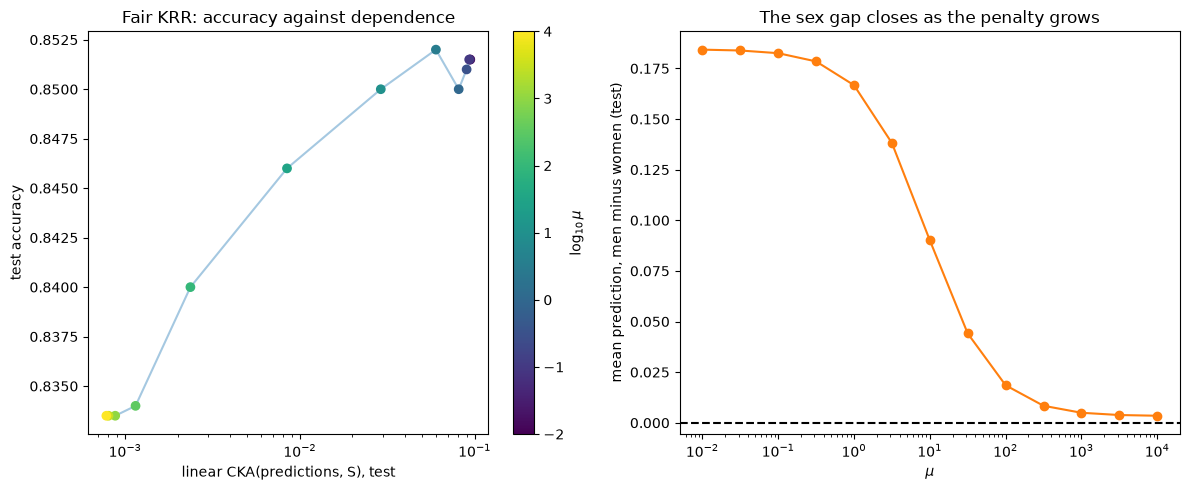

In [6]:
acc = np.array([r["acc"] for r in front])
cka_lin = np.array([r["cka_lin"] for r in front])
gap = np.array([r["gap"] for r in front])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
points = ax.scatter(cka_lin, acc, c=np.log10(mus), cmap="viridis", zorder=3)
ax.plot(cka_lin, acc, "-", color="C0", alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("linear CKA(predictions, S), test")
ax.set_ylabel("test accuracy")
ax.set_title("Fair KRR: accuracy against dependence")
fig.colorbar(points, ax=ax, label=r"$\log_{10}\mu$")
ax = axes[1]
ax.semilogx(mus, gap, "o-", color="C1")
ax.axhline(0.0, color="k", ls="--")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("mean prediction, men minus women (test)")
ax.set_title("The sex gap closes as the penalty grows")
fig.tight_layout()
plt.show()

## A nonlinear penalty: an MLP trained with `kl.cka`

A network has no closed form, so the penalty goes into the loss and is differentiated. `kl.cka` is safe here: a constant prediction (a collapsed network) has CKA 0 with a zero gradient, instead of $0/0$. The loss is

$$\frac1B\sum_i (f(x_i) - y_i)^2 + \mu\,\mathrm{CKA}_u\big(f(x), s\big),$$

with an RBF kernel on the predictions (lengthscale fixed from the target, as above), an RBF on $S$, and the unbiased estimator, which needs at least 4 points per batch.

Training uses [pipekit-train](https://github.com/jejjohnson/pipekit)'s `TrainingLoop` with its Equinox backend. The objective is a `TrainTask`: any object with `loss_fn(model, batch, key) -> (loss, metrics)`. The Equinox backend batches `(input, target)` pairs, so the protected attributes travel in the target, next to $y$. A small indexable `TrainingDataset` lets the backend shuffle each epoch, which matters for a batch statistic like CKA.

In [7]:
class ArrayDataset(TrainingDataset):
    """In-memory (input, target) pairs; indexable, so batches are shuffled."""

    def __init__(self, inputs, targets, name):
        super().__init__()
        self.inputs, self.targets = np.asarray(inputs), np.asarray(targets)
        self.name = name

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, i):
        return self.inputs[i], self.targets[i]

    def __iter__(self):
        for i in range(len(self)):
            yield self[i]

    def get_config(self):
        return {"name": self.name, "n": len(self)}


class CKAPenalisedMSE:
    """A pipekit TrainTask: MSE plus mu times the unbiased RBF CKA with s."""

    def __init__(self, mu, ell_f):
        self.mu, self.ell_f = mu, ell_f

    def loss_fn(self, model, batch, key):
        x, target = batch
        y, s = target[:, 0], target[:, 1:]
        pred = jax.vmap(model)(x)[:, 0]
        mse = jnp.mean((pred - y) ** 2)
        k_f = kl.RBF(self.ell_f)
        f = einx.id("n -> n 1", pred)
        cka = kl.cka(k_f, kl.RBF(1.0), f, s, estimator="unbiased")
        return mse + self.mu * cka, {"mse": mse, "cka": cka}


train_set = ArrayDataset(
    X, jnp.concatenate([einx.id("n -> n 1", y), S], axis=-1), "adult"
)

In [8]:
t0 = time.perf_counter()
networks = {}
for mu in [0.0, 1.0, 10.0]:
    mlp = eqx.nn.MLP(X.shape[1], 1, 32, 2, key=jax.random.key(0))
    loop = TrainingLoop(
        model_op=EquinoxModelOp(mlp),
        dataset=train_set,
        task=CKAPenalisedMSE(mu, ell_f),
        optimizer_config={"name": "adamw", "learning_rate": 3e-3},
        max_steps=300,
        batch_size=256,
        seed=0,
        backend="equinox",
    )
    trained, artifact = loop.run()
    networks[mu] = scores(jax.vmap(trained.module)(X_test)[:, 0])
    last = artifact.backend_info["final_metrics"]
    print(
        f"mu = {mu:4.1f}: last batch mse {last['mse']:.4f}, cka {last['cka']:+.4f}; "
        f"{artifact.backend_info['total_seconds']:.1f} s"
    )
mlp_seconds = time.perf_counter() - t0

print(f"\nthree networks in {mlp_seconds:.1f} s")
print("  mu    acc     mse  CKA lin  CKA rbf  sex gap")
for mu, r in networks.items():
    print(
        f"{mu:4.1f}  {r['acc']:.4f}  {r['mse']:.4f}  {r['cka_lin']:.4f}  "
        f"{r['cka_rbf']:.4f}  {r['gap']:+.3f}"
    )

mu =  0.0: last batch mse 0.0830, cka +0.1009; 33.8 s


mu =  1.0: last batch mse 0.1034, cka -0.0045; 28.8 s


mu = 10.0: last batch mse 0.1280, cka -0.0038; 36.5 s

three networks in 106.6 s
  mu    acc     mse  CKA lin  CKA rbf  sex gap
 0.0  0.8470  0.1088  0.0905  0.0964  +0.197
 1.0  0.8335  0.1224  0.0014  0.0019  +0.013
10.0  0.7960  0.1420  0.0014  0.0007  -0.014


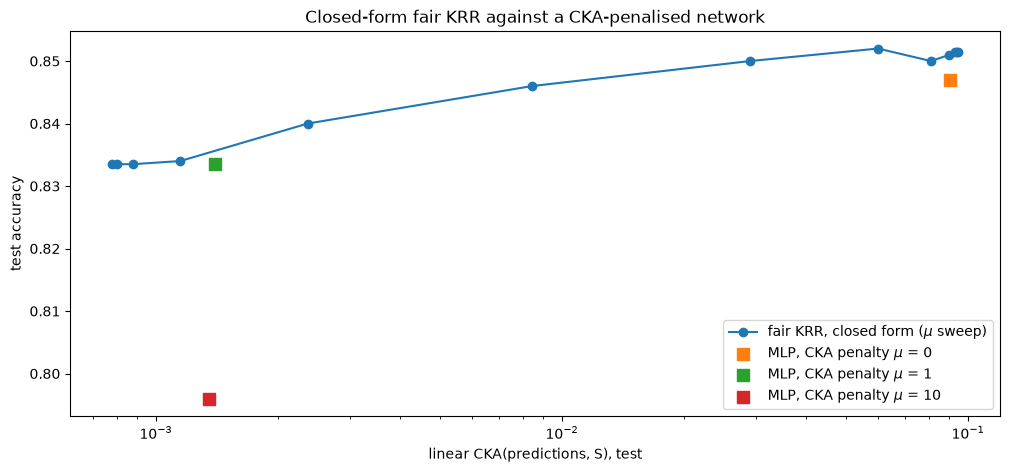

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cka_lin, acc, "o-", color="C0", label=r"fair KRR, closed form ($\mu$ sweep)")
for i, (mu, r) in enumerate(networks.items()):
    ax.scatter(
        r["cka_lin"],
        r["acc"],
        marker="s",
        s=80,
        color=f"C{i + 1}",
        zorder=3,
        label=f"MLP, CKA penalty $\\mu$ = {mu:g}",
    )
ax.set_xscale("log")
ax.set_xlabel("linear CKA(predictions, S), test")
ax.set_ylabel("test accuracy")
ax.set_title("Closed-form fair KRR against a CKA-penalised network")
ax.legend()
plt.show()

The unpenalised network ($\mu = 0$) reaches a test accuracy of 0.8470, a little below plain KRR's 0.8515, with about the same dependence (linear CKA 0.0905, sex gap +0.197). At $\mu = 1$ the CKA penalty brings the linear CKA down to 0.0014 and the gap to +0.013, at an accuracy of 0.8335: close to fair KRR at $\mu \approx 300$ (0.8340 and 0.0011), just below the closed-form curve. At $\mu = 10$ the network over-corrects. The gap changes sign ($-0.014$) and accuracy falls to 0.7960, not far above the majority-class 0.7590, while the linear CKA does not fall any further. What the nonlinear penalty does buy is a lower RBF CKA, 0.0019 at $\mu = 1$ and 0.0007 at $\mu = 10$, against 0.0027 at the end of the closed-form curve. The per-batch CKA in the training log is slightly negative, as the unbiased estimator can be near zero. These networks are untuned (300 Adam steps); the closed form gives the whole curve from 13 linear solves, with no optimiser at all.

## LapRLS: semi-supervised classification on two moons

Two interleaved half-moons, 400 points, and **one label per moon**. Plain KRR sees only the two labelled points and draws a boundary between them. LapRLS fits all 400 points with a mask that keeps only the two labels in the data term, and adds the smoothness of $f$ along a 10-nearest-neighbour graph (heat-kernel weights), so the boundary has to avoid cutting graph edges. Both use an RBF with lengthscale 0.3 and $\lambda = 10^{-4}$; the labels are $\pm 1$, classified by sign.

In [10]:
moons, moon = make_moons(400, noise=0.07, random_state=0)
moons, moon = jnp.asarray(moons), jnp.asarray(2.0 * moon - 1.0)
labelled = jnp.array([int(jnp.argmax(moon == -1)), int(jnp.argmax(moon == 1))])
mask = jnp.zeros(len(moons), dtype=bool).at[labelled].set(True)
W = kl.adjacency_matrix(kl.nearest_neighbors(moons, 10))
graph_penalty = kl.laplacian_penalty(W)
kernel = kl.RBF(0.3)

plain = kl.KRR(kernel, regularization=1e-4).fit(moons[labelled], moon[labelled])
plain_acc = float(jnp.mean(jnp.sign(plain.predict(moons)) == moon))
print(f"plain KRR on 2 labels: accuracy {plain_acc:.4f}")

t0 = time.perf_counter()
laprls_fits = {}
for mu in [1e-1, 1.0, 1e1, 1e2, 1e3]:
    laprls = kl.KRR(kernel, regularization=1e-4, penalty_weight=mu)
    laprls = laprls.fit(moons, moon, mask=mask, penalty=graph_penalty)
    laprls_fits[mu] = laprls
    accuracy = float(jnp.mean(jnp.sign(laprls.predict(moons)) == moon))
    print(f"LapRLS mu = {mu:7.1f}: accuracy {accuracy:.4f}")
print(f"{len(laprls_fits)} LapRLS fits in {time.perf_counter() - t0:.1f} s")

plain KRR on 2 labels: accuracy 0.7850


LapRLS mu =     0.1: accuracy 0.8025
LapRLS mu =     1.0: accuracy 0.8100
LapRLS mu =    10.0: accuracy 0.8575
LapRLS mu =   100.0: accuracy 0.9575
LapRLS mu =  1000.0: accuracy 0.9950
5 LapRLS fits in 2.0 s


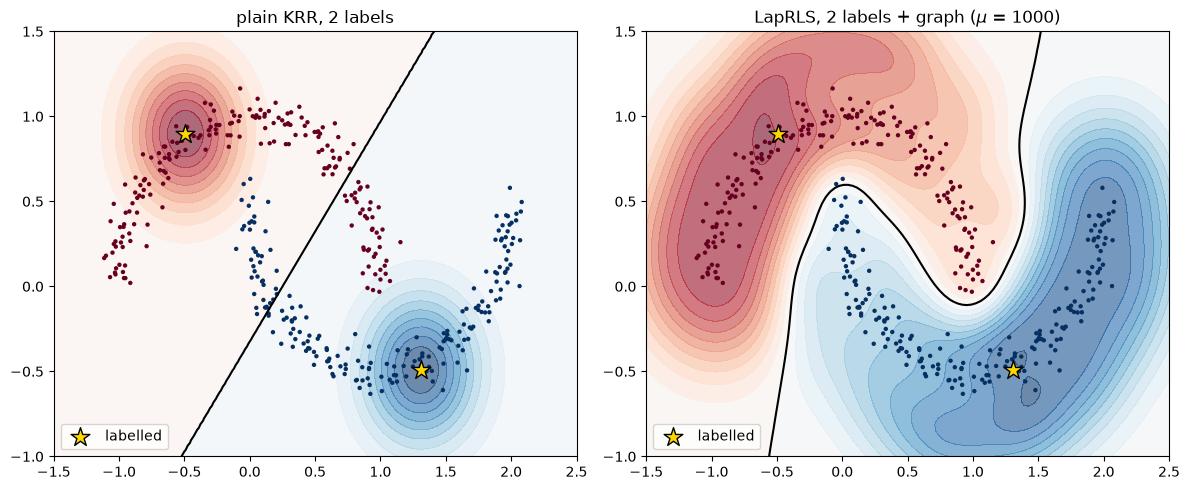

In [11]:
grid_1d = [jnp.linspace(-1.5, 2.5, 120), jnp.linspace(-1.0, 1.5, 80)]
g0, g1 = jnp.meshgrid(*grid_1d)
grid = jnp.stack([g0, g1], axis=-1)
grid_points = einx.id("a b d -> (a b) d", grid)
shape = {"a": g0.shape[0], "b": g0.shape[1]}
best_mu = 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in [
    (axes[0], plain, "plain KRR, 2 labels"),
    (axes[1], laprls_fits[best_mu], f"LapRLS, 2 labels + graph ($\\mu$ = {best_mu:g})"),
]:
    surface = einx.id("(a b) -> a b", model.predict(grid_points), **shape)
    ax.contourf(g0, g1, surface, levels=20, cmap="RdBu", alpha=0.6)
    ax.contour(g0, g1, surface, levels=[0.0], colors="k")
    ax.scatter(moons[:, 0], moons[:, 1], c=moon, cmap="RdBu", s=10, edgecolor="none")
    ax.scatter(
        moons[labelled, 0],
        moons[labelled, 1],
        c="gold",
        s=200,
        marker="*",
        edgecolor="k",
        label="labelled",
    )
    ax.set_title(title)
    ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

Plain KRR on the two labelled points classifies 0.7850 of the 400 points correctly: its boundary is roughly the perpendicular bisector of the two stars, which cuts both moons. LapRLS improves steadily with $\mu$, from 0.8025 at $\mu = 0.1$ to 0.8575 at $\mu = 10$, 0.9575 at $\mu = 100$ and 0.9950 at $\mu = 1000$ (plotted). The zero contour then runs through the gap between the moons, where the graph has few edges to cut. Only the penalty and the mask differ from the fair-KRR fits above: it is the same estimator and the same linear system.

## Supervised and fair kernel PCA

Back to the census, on the first 800 training rows. `KernelPCA(target_weight=γ)` with a `Linear` target kernel adds $\gamma$ times the linear-kernel HSIC between the components and a target to the variance it maximises. With the income as target and $\gamma > 0$ the components line up with income (supervised KPCA); with the protected attributes as target and $\gamma < 0$ they are pushed away from them (fair KPCA). We measure both with the linear CKA between the two-component embedding and each variable.

In [12]:
n_kpca = 800
Xk, yk, Sk = X[:n_kpca], einx.id("n -> n 1", y[:n_kpca]), S[:n_kpca]
lin = kl.Linear()


def kpca(gamma, target):
    model = kl.KernelPCA(
        kl.RBF(ell), n_components=2, target_kernel=lin, target_weight=gamma
    )
    return model.fit(Xk, target=target).embedding


t0 = time.perf_counter()
gammas = [0.0, 1.0, 10.0, 100.0, 1000.0]
supervised = [kpca(g, yk) for g in gammas]
fair_kpca = [kpca(-g, Sk) for g in gammas]
print(f"{2 * len(gammas)} kernel PCA fits in {time.perf_counter() - t0:.1f} s")
print("  |gamma|  supervised: CKA(Z,y) CKA(Z,S)   fair: CKA(Z,y) CKA(Z,S)")
for g, Zs, Zf in zip(gammas, supervised, fair_kpca, strict=True):
    print(
        f"{g:9.0f}  {float(kl.cka(lin, lin, Zs, yk)):19.4f} "
        f"{float(kl.cka(lin, lin, Zs, Sk)):8.4f}  "
        f"{float(kl.cka(lin, lin, Zf, yk)):12.4f} "
        f"{float(kl.cka(lin, lin, Zf, Sk)):8.4f}"
    )

10 kernel PCA fits in 6.1 s
  |gamma|  supervised: CKA(Z,y) CKA(Z,S)   fair: CKA(Z,y) CKA(Z,S)


        0               0.1941   0.0569        0.1941   0.0569


        1               0.2012   0.0582        0.1919   0.0518


       10               0.2194   0.0645        0.1715   0.0212


      100               0.2308   0.0703        0.1242   0.0012


     1000               0.2323   0.0712        0.0947   0.0000


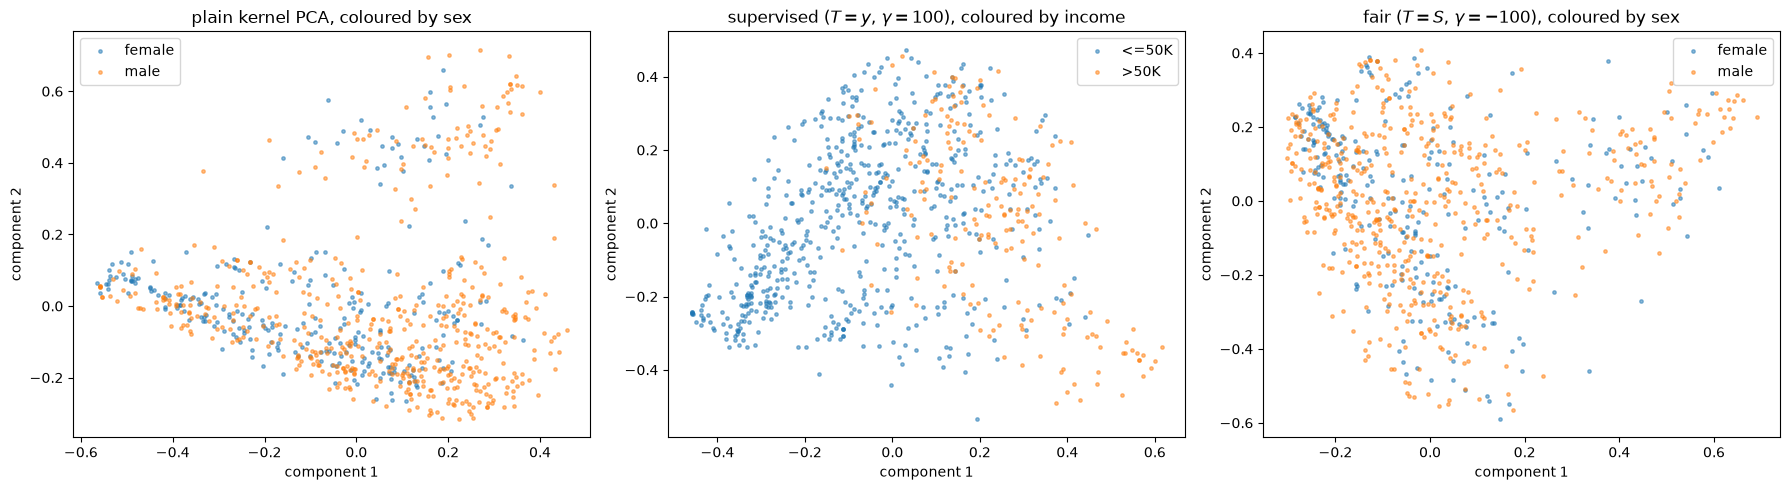

In [13]:
panels = [
    (supervised[0], "plain kernel PCA", "sex"),
    (supervised[3], r"supervised ($T = y$, $\gamma = 100$)", "income"),
    (fair_kpca[3], r"fair ($T = S$, $\gamma = -100$)", "sex"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (Z, title, colour_by) in zip(axes, panels, strict=True):
    c = Sk[:, 0] if colour_by == "sex" else yk[:, 0]
    names = ("female", "male") if colour_by == "sex" else ("<=50K", ">50K")
    for value, name, colour in [(0.0, names[0], "C0"), (1.0, names[1], "C1")]:
        sel = c == value
        ax.scatter(Z[sel, 0], Z[sel, 1], s=6, color=colour, alpha=0.5, label=name)
    ax.set_title(f"{title}, coloured by {colour_by}")
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.legend()
fig.tight_layout()
plt.show()

Supervised kernel PCA moves towards the income as $\gamma$ grows: the CKA between the embedding and $y$ rises from 0.1941 to 0.2308 at $\gamma = 100$ and 0.2323 at $\gamma = 1000$. The CKA with $S$ rises too, from 0.0569 to 0.0712, because income and sex are dependent in this data, so supervising for one pulls in the other. Fair kernel PCA does the opposite: the CKA with $S$ falls from 0.0569 to 0.0012 at $\gamma = -100$ and to 0.0000 (four decimals) at $\gamma = -1000$. It costs information about income as well, whose CKA falls from 0.1941 to 0.1242 and then 0.0947. Every fit is the dense eigendecomposition of plain kernel PCA plus one small symmetric eigenproblem, with no gradient descent and no soft orthogonality constraint.

## Denoising by projection and pre-image

Kernel PCA projects onto the leading components in feature space, where noise spreads over the many small ones. To get back to pixels, `fit_inverse_transform=True` learns the pre-image map from components to inputs by KRR on the training pairs (Bakir, Weston & Schölkopf, 2004); `inverse_transform` applies it. We fit on 1,000 clean 8×8 digits (pixels scaled to $[0, 1]$), add Gaussian noise of standard deviation 0.25 to 300 held-out digits, and compare RBF kernel PCA with linear PCA at the same number of components. For linear PCA the pre-image kernel is `Linear() + Constant()`: KRR has no intercept, so a purely linear map from centred components cannot put the pixel means back.

In [14]:
digits = load_digits()
pixels = jnp.asarray(digits.data / 16.0)
perm = np.random.default_rng(0).permutation(len(pixels))
clean_train, clean_test = pixels[perm[:1000]], pixels[perm[1000:1300]]
noise = 0.25 * jax.random.normal(jax.random.key(1), clean_test.shape)
noisy_test = clean_test + noise
ell_digits = kl.estimate_lengthscale(clean_train)
noisy_mse = float(jnp.mean((noisy_test - clean_test) ** 2))
print(f"digit lengthscale (median) = {float(ell_digits):.3f}")
print(f"noisy MSE = {noisy_mse:.4f}")

t0 = time.perf_counter()
denoised = {}
print("  components  linear PCA  RBF kernel PCA")
for n_components in [8, 16, 32, 64]:
    rbf_pca = kl.KernelPCA(
        kl.RBF(ell_digits), n_components=n_components, fit_inverse_transform=True
    ).fit(clean_train)
    linear_pca = kl.KernelPCA(
        kl.Linear(),
        n_components=n_components,
        fit_inverse_transform=True,
        inverse_kernel=kl.Linear() + kl.Constant(),
    ).fit(clean_train)
    for name, model in [("linear", linear_pca), ("rbf", rbf_pca)]:
        denoised[name, n_components] = model.inverse_transform(
            model.transform(noisy_test)
        )
    errors = {
        name: float(jnp.mean((denoised[name, n_components] - clean_test) ** 2))
        for name in ("linear", "rbf")
    }
    print(f"{n_components:12d}  {errors['linear']:10.4f}  {errors['rbf']:14.4f}")
print(f"8 kernel PCA fits with pre-images in {time.perf_counter() - t0:.1f} s")

digit lengthscale (median) = 3.060
noisy MSE = 0.0614
  components  linear PCA  RBF kernel PCA


           8      0.0327          0.0275


          16      0.0270          0.0208


          32      0.0320          0.0186


          64      0.0423          0.0183
8 kernel PCA fits with pre-images in 16.7 s


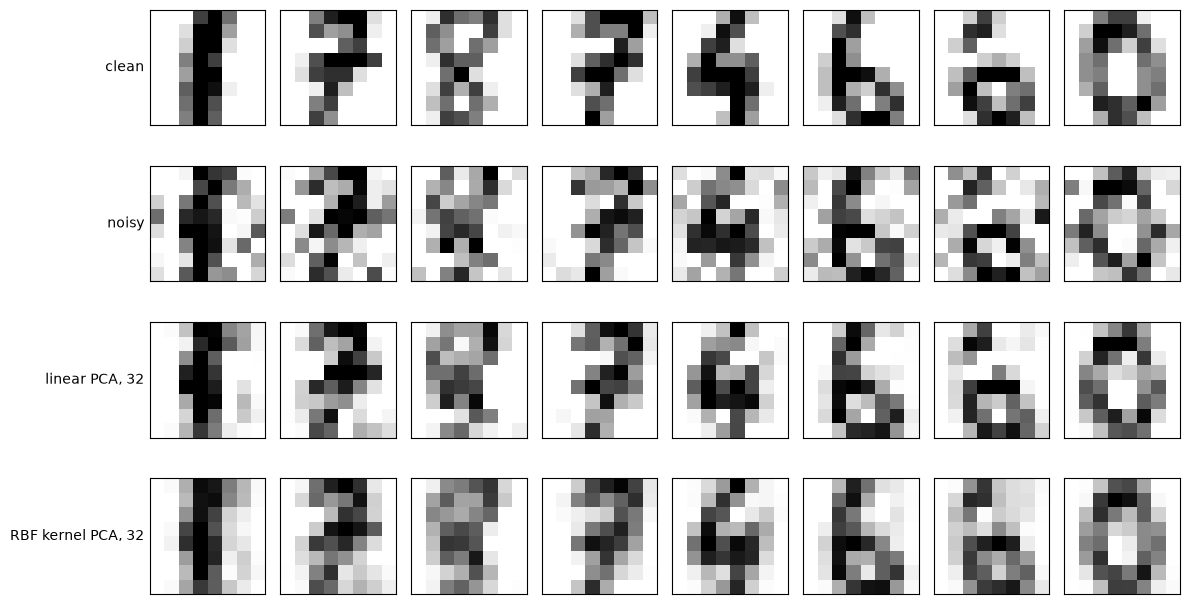

In [15]:
show = 8
rows = [
    ("clean", clean_test),
    ("noisy", noisy_test),
    ("linear PCA, 32", denoised["linear", 32]),
    ("RBF kernel PCA, 32", denoised["rbf", 32]),
]
fig, axes = plt.subplots(len(rows), show, figsize=(12, 6.5))
for r, (name, images) in enumerate(rows):
    for c in range(show):
        ax = axes[r, c]
        ax.imshow(
            einx.id("(h w) -> h w", images[c], h=8), cmap="gray_r", vmin=0, vmax=1
        )
        ax.set_xticks([])
        ax.set_yticks([])
    axes[r, 0].set_ylabel(name, rotation=0, ha="right", va="center")
fig.tight_layout()
plt.show()

The noisy digits have an MSE of 0.0614 against the clean ones. Linear PCA does best at 16 components (0.0270) and gets worse with more (0.0423 at 64), as more of the noise passes through the projection. RBF kernel PCA improves with every component added: 0.0275 at 8, 0.0186 at 32 and 0.0183 at 64, a third of the noisy MSE and about 1.5 times lower than the best linear PCA. The pre-image is a `KRR` fitted on the training pairs, so the reconstructions are smooth, slightly blurred combinations of training digits.

## Summary

- `KRR(penalty_weight=μ).fit(X, y, penalty=hsic_penalty(Linear(), S))` is fair kernel ridge regression in closed form. With a linear kernel on $S$ each $\mu$ is $P + 1$ KRR solves, so the whole accuracy–dependence curve is a loop over $\mu$. On Adult it took the linear CKA with sex and race from 0.094 to about 0.001 for 1.8 points of accuracy.
- A nonlinear dependence penalty is a line in a loss: `mse + mu * kl.cka(...)`, safe to differentiate even for a collapsed network. Written as a pipekit-train `TrainTask`, it trains with `TrainingLoop`; here it came close to the closed-form curve at $\mu = 1$ and over-corrected at $\mu = 10$.
- `laplacian_penalty` plus a `mask` turns the same estimator into LapRLS: from two labels, 0.9950 accuracy on two moons against 0.7850 for plain KRR.
- `KernelPCA(target_kernel=..., target_weight=γ)` is supervised ($\gamma > 0$) or fair ($\gamma < 0$) kernel PCA, from one eigenproblem.
- `KernelPCA(fit_inverse_transform=True)` learns a pre-image map by KRR; projecting noisy digits onto 64 RBF components and mapping back cut the MSE by a factor of three.

In [16]:
print(f"notebook runtime: {time.perf_counter() - notebook_start:.0f} s")

notebook runtime: 226 s
